<a href="https://colab.research.google.com/github/ges45-learn/Module5/blob/main/SCS_Colab_Notebook_W5_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Course notebook notes

Throughout this notebook you will be taught how to work with Colab and OpenLane. More specifically, you will use this Notebook to:

* compare IC designs from 1970s and 2020s  
* explore a basic semiconductor layout, identifying the materials that are included in it
* study and characterise a given standard library cell.
* look at a design tool, explore it and consider what it is doing
* look at a design tool, inserting input/output (I/O) pads for wiring bonding and experience verification

**NOTE 1:** In module 1, we asked you to create a Google and Colab account. For optimal experience, you must be logged into the Google account that you created every time you work with this file.

**NOTE 2:** If you have not done so already, be sure to make a copy of this notebook in your drive. This will help you retain any changes you make and ensure a smooth journey through the following sections.

---

# Imports, authentication and preparation
Running the following cells will import all the data we need for this notebook to work. Simply select the code cell below and it will import all of these important packages.

Note that you will need to run these every time you open this notebook. Be sure to complete this step before attempting any of the tasks in this notebook.

Setting up the OpenLane runtime environment

For this to work, we want to:
* install OpenLane (v2) and its dependencies
* download and set up [open source sky130 PDK](https://github.com/google/skywater-pdk/) by Google and Skywater.

Created by Efabless, *edited by Dr Matthew Tang*.


In [ ]:
# @title Setup Nix {display-mode: "form"}
# @markdown Nix is a package manager with an emphasis on reproducible builds,
# @markdown     and it is the primary method for installing OpenLane2.
# @markdown
# @markdown     This step installs the Nix package manager and enables the
# @markdown     experimental 'flakes' feature.
# @markdown
# If you're not in a Colab, this just sets the environment variables.
# You will need to install Nix and enable flakes on your own following
# [this guide](https://openlane2.readthedocs.io/en/stable/getting_started/common/nix_installation/index.html).
import os
import sys
import shutil

os.environ["LOCALE_ARCHIVE"] = "/usr/lib/locale/locale-archive"

if "google.colab" in sys.modules:
    if shutil.which("nix-env") is None:
        !curl -L https://nixos.org/nix/install | bash -s -- --daemon --yes
        !echo "extra-experimental-features = nix-command flakes" >> /etc/nix/nix.conf
        !killall nix-daemon
else:
    if shutil.which("nix-env") is None:
        raise RuntimeError("Nix is not installed!")

os.environ["PATH"] = f"/nix/var/nix/profiles/default/bin/:{os.getenv('PATH')}"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  4499  100  4499    0     0   5562      0 --:--:-- --:--:-- --:--:-- 31907
downloading Nix 2.35.2 binary tarball for x86_64-linux from 'https://releases.nixos.org/nix/nix-2.35.2/nix-2.35.2-x86_64-linux.tar.xz' to '/tmp/nix-binary-tarball-unpack.ruxruJz3RG'...
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 25.8M  100 25.8M    0     0  33.5M      0 --:--:-- --:--:-- --:--:-- 33.6M
Note: a multi-user installation is possible. See https://nix.dev/manual/nix/stable/installation/installing-binary.html#multi-user-installation
Switching to the Multi-user Installer
Welcome to the Multi-User Nix Installation

This installation tool will set up yo

In [ ]:
# @title Get OpenLane2 and SKY130 Open PDK {"display-mode":"form"}
# @markdown Click the ▷ button to download and install OpenLane.
# @markdown
# @markdown     This will install OpenLane's tool dependencies using Nix,
# @markdown     and OpenLane itself using PIP.
# @markdown
# @markdown     Note that `python3-tk` may need to be installed using your OS's
# @markdown     package manager.
import os
import subprocess
import IPython

openlane_version = "main"  # @param {key:"OpenLane Version", type:"string"}

if openlane_version == "latest":
    openlane_version = "main"

pdk_root = "~/.volare"  # @param {key:"PDK Root", type:"string"}

pdk_root = os.path.expanduser(pdk_root)

pdk = "sky130"  # @param {key:"PDK (without the variant)", type:"string"}

openlane_ipynb_path = os.path.join(os.getcwd(), "openlane_ipynb")

display(IPython.display.HTML("<h3>Downloading OpenLane…</a>"))

TESTING_LOCALLY = False
!rm -rf {openlane_ipynb_path}
!mkdir -p {openlane_ipynb_path}
if TESTING_LOCALLY:
    !ln -s {os.getcwd()} {openlane_ipynb_path}
else:
    !curl -L "https://github.com/efabless/openlane2/tarball/{openlane_version}" | tar -xzC {openlane_ipynb_path} --strip-components 1

try:
    import tkinter
except ImportError:
    if "google.colab" in sys.modules:
        !sudo apt-get install python-tk

try:
    import tkinter
except ImportError as e:
    display(
        IPython.display.HTML(
            '<h3 style="color: #800020";>❌ Failed to import the <code>tkinter</code> library for Python, which is required to load PDK configuration values. Make sure <code>python3-tk</code> or equivalent is installed on your system.</a>'
        )
    )
    raise e from None


display(IPython.display.HTML("<h3>Downloading OpenLane's dependencies…</a>"))
try:
    subprocess.check_call(
        ["nix", "profile", "install", ".#colab-env", "--accept-flake-config"],
        cwd=openlane_ipynb_path,
    )
except subprocess.CalledProcessError as e:
    display(
        IPython.display.HTML(
            '<h3 style="color: #800020";>❌ Failed to install binary dependencies using Nix…</h3>'
        )
    )

display(IPython.display.HTML("<h3>Downloading Python dependencies using PIP…</a>"))
try:
    subprocess.check_call(
        ["pip3", "install", "."],
        cwd=openlane_ipynb_path,
    )
except subprocess.CalledProcessError as e:
    display(
        IPython.display.HTML(
            '<h3 style="color: #800020";>❌ Failed to install Python dependencies using PIP…</h3>'
        )
    )
    raise e from None

display(IPython.display.HTML("<h3>Downloading PDK…</a>"))

#pdk_tmp = user_workspace_path + '/.volare'
#if os.path.exists(pdk_tmp):
#  IPython.display.HTML('<p>PDK found in user workspace. Linking ...</p>')


import volare

volare.enable(
    volare.get_volare_home(pdk_root),
    pdk,
    open(
        os.path.join(openlane_ipynb_path, "openlane", "open_pdks_rev"),
        encoding="utf8",
    )
    .read()
    .strip(),
)
# create symlink for PDK
#!ln -s {pdk_root} ~/.volare
sys.path.insert(0, openlane_ipynb_path)

display(IPython.display.HTML("<h3>⭕️ Done.</a>"))

import logging

# Remove the stupid default colab logging handler
logging.getLogger().handlers.clear()

# link the latest versions with the assumed directory name
!cd /root/.volare/volare/sky130/versions && ln -s `cat ../current` bdc9412b3e468c102d01b7cf6337be06ec6e9c9a

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 9527k    0 9527k    0     0  9385k      0 --:--:--  0:00:01 --:--:-- 15.7M


Version 0fe599b2afb6708d281543108caf8310912f54af not found locally, attempting to download…

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

Version 0fe599b2afb6708d281543108caf8310912f54af enabled for the sky130 PDK.

## Quick check

After running the above cells, you should see the version number of OpenLane. If you see that, you are ready to run the tasks below.

In [ ]:
import openlane
print(openlane.__version__)

2.3.10


## Utility functions

These functions are required to generate high-quality images from the OpenLane's outputs (GDSII layout). Execute the code box once before beginning any tasks in the course.

[1] Create images from GDSII layout (`gds_render.py`).

This short Python program generates a high-resolution image from the GDSII physical layout provided, then inspect the images closely in your browser. (You may download the image too).

Recommended resolution:

Module 1: 2,000 pixels

Other modules: 1,000 pixels

In [ ]:
%%writefile /content/gds_render.py
# @markdown You may adjust the resolution of the image by modifying the value below. The default is 1,000 pixels.
#!/usr/bin/env python3
# Copyright (c) 2021-2022 Efabless Corporation
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Original Copyright Follows
#
# BSD 3-Clause License
#
# Copyright (c) 2018, The Regents of the University of California
# All rights reserved.
#
# Redistribution and use in source and binary forms, with or without
# modification, are permitted provided that the following conditions are met:
#
# * Redistributions of source code must retain the above copyright notice, this
#   list of conditions and the following disclaimer.
#
# * Redistributions in binary form must reproduce the above copyright notice,
#   this list of conditions and the following disclaimer in the documentation
#   and/or other materials provided with the distribution.
#
# * Neither the name of the copyright holder nor the names of its
#   contributors may be used to endorse or promote products derived from
#   this software without specific prior written permission.
#
# THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS AND CONTRIBUTORS "AS IS"
# AND ANY EXPRESS OR IMPLIED WARRANTIES, INCLUDING, BUT NOT LIMITED TO, THE
# IMPLIED WARRANTIES OF MERCHANTABILITY AND FITNESS FOR A PARTICULAR PURPOSE ARE
# DISCLAIMED. IN NO EVENT SHALL THE COPYRIGHT HOLDER OR CONTRIBUTORS BE LIABLE
# FOR ANY DIRECT, INDIRECT, INCIDENTAL, SPECIAL, EXEMPLARY, OR CONSEQUENTIAL
# DAMAGES (INCLUDING, BUT NOT LIMITED TO, PROCUREMENT OF SUBSTITUTE GOODS OR
# SERVICES; LOSS OF USE, DATA, OR PROFITS; OR BUSINESS INTERRUPTION) HOWEVER
# CAUSED AND ON ANY THEORY OF LIABILITY, WHETHER IN CONTRACT, STRICT LIABILITY,
# OR TORT (INCLUDING NEGLIGENCE OR OTHERWISE) ARISING IN ANY WAY OUT OF THE USE
# OF THIS SOFTWARE, EVEN IF ADVISED OF THE POSSIBILITY OF SUCH DAMAGE.

import pya
import sys

def render(
    input: str,
    output: str,
):
    PDK = '~/.volare/volare/sky130/versions/bdc9412b3e468c102d01b7cf6337be06ec6e9c9a'
    lyt = f'{PDK}/sky130A/libs.tech/klayout/tech/sky130A.lyt'
    lyp = f'{PDK}/sky130A/libs.tech/klayout/tech/sky130A.lyp'
    lym = f'{PDK}/sky130A/libs.tech/klayout/tech/sky130A.lyt'

    img_res = 1000 # @param {key:"image resolution", type:"number"}
    print(f"image resolution: {img_res}")
    # display ONLY the layers in the following list
    selected_layers = [
        "diff.",
        "dnwell.",
        "li1.",
        "licon1.",
        "mcon.",
        "met1.",
        "met2.",
        "met3.",
        "met4.",
        "met5.",
        #"vnpc.",
        #"vnsdm.",
        #"vnwell.",
        "poly.",
        "psdm.",
        "pwell.",
        "tap.",
        "via.",
        "via2.",
        "via3.",
        "via4."
    ]

    try:
        gds = input.endswith(".gds")

        # Load technology file
        tech = pya.Technology()
        tech.load(lyt)

        layout_options = None

        view = pya.LayoutView()
        view.load_layer_props(lyp)

        if gds:
            view.load_layout(input)
        else:
            view.load_layout(input, layout_options, lyt)

        view.max_hier()

        # control the visibility of the layers
        for layer in view.each_layer():
            layer.visible = False
            if '122/16@1' in layer.source: # grid and ruler
                layer.visible = True
            for t in selected_layers:
                if layer.name.startswith(t):
                    layer.visible = True

        pixels = view.get_pixels_with_options(img_res, img_res)

        with open(output, "wb") as f:
            f.write(pixels.to_png_data())

    except Exception as e:
        print(e)
        exit(1)


if __name__ == "__main__":
    gds_file = ''
    if len(sys.argv) >= 2:
        gds_file = sys.argv[1]
    else:
        quit('Please provide a GDS file.')

    out_file = 'output.png'
    if len(sys.argv) >= 3:
        out_file = sys.argv[2]
    print(f"Input GDS file: {gds_file}")
    print(f"Output PNG file: {out_file}")

    render(gds_file, out_file)
    print("done.")

Writing /content/gds_render.py


[2] Install a customised render function.

In [ ]:
%%writefile /content/openlane_ipynb/openlane/scripts/klayout/render.py
#!/usr/bin/env python3
# @markdown This makes ``display()`` to generate an additional png image (``/content/openlane_run/output.png``) of a higher resolution (default: 5000 pixels).
# More information about layers can be found at this
# [link](https://skywater-pdk.readthedocs.io/en/main/rules/layers.html). To hide the layer in the output image, comment off from the list.
#
# Copyright (c) 2021-2022 Efabless Corporation
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

from typing import Tuple
import pya
import click
@click.command()
@click.option("-o", "--output", required=True)
@click.option("-l", "--input-lef", "input_lefs", multiple=True,)
@click.option( "-T", "--lyt", required=True, help="KLayout .lyt file",)
@click.option( "-P", "--lyp", required=True, help="KLayout .lyp file",)
@click.option( "-M", "--lym", required=True, help="KLayout .map (LEF/DEF layer map) file",)
@click.argument("input")
def render(input_lefs: Tuple[str, ...], output: str, lyt: str, lyp: str, lym: str, input: str,):
    image_res = 5000 # output image resolution = 5000 pixels
    # display ONLY the layers in the following list
    selected_layers = [
        "diff.",
        "dnwell.",
        "li1.",
        "licon1.",
        "mcon.",
        "met1.",
        "met2.",
        "met3.",
        "met4.",
        "met5.",
        #"vnpc.",
        #"vnsdm.",
        #"vnwell.",
        "poly.",
        "psdm.",
        "pwell.",
        "tap.",
        "via.",
        "via2.",
        "via3.",
        "via4."
    ]

    try:
        gds = input.endswith(".gds")

        # Load technology file
        tech = pya.Technology()
        tech.load(lyt)

        layout_options = None
        if not gds:
            layout_options = tech.load_layout_options
            layout_options.lefdef_config.map_file = lym
            layout_options.lefdef_config.macro_resolution_mode = 1
            layout_options.lefdef_config.read_lef_with_def = False
            layout_options.lefdef_config.lef_files = list(input_lefs)

        view = pya.LayoutView()
        view.load_layer_props(lyp)

        if gds:
            view.load_layout(input)
        else:
            view.load_layout(input, layout_options, lyt)

        view.max_hier()

        # control the visibility of the layers
        for layer in view.each_layer():
            layer.visible = False
            if '122/16@1' in layer.source: # grid and ruler
                layer.visible = True
            for t in selected_layers:
                if t in layer.name:
                    layer.visible = True

        pixels = view.get_pixels_with_options(1000, 1000)

        with open(output, "wb") as f:
            f.write(pixels.to_png_data())

        # save an image of larger resolution
        pixels = view.get_pixels_with_options(image_res, image_res)
        with open("/content/openlane_run/output.png", "wb") as f:
            f.write(pixels.to_png_data())

    except Exception as e:
        print(e)
        exit(1)

if __name__ == "__main__":
    render()

Overwriting /content/openlane_ipynb/openlane/scripts/klayout/render.py


Now you may proceed with the actual task for the module.


---



# Module 5: Assembly, testing and packaging
In this section you will work on your fifth module task. Before attempting it, please ensure that you are working in your own copy of the notebook and you have successfully run all the cells above.

In this task, we are going to prepare an inverter design for assembly and packaging using the popular wire bonding technology.

---

**What you need to do**

Firstly, set up Nix, OpenLane2 and SKY130 Open PDK in your Colab runtime environment, and then action the following steps:
1. Write the design file and install the utility function.
1. Run automatic floorplanning.
1. Run manual floorplanning with fixed die size.
1. Work out the expected die size with I/O pads inserted.

The following sections contain the code and packages you need to complete these steps.

## Step 1: Write the design file

Run the following code to create a verilog file for a 32-bit inverter.

In [ ]:
%%writefile /content/inverter32.v
module inverter32 (
    input  wire [31:0] a_in,
    output wire [31:0] y_out
);

    assign y_out = ~a_in;
endmodule

Writing /content/inverter32.v


Run the next box to install a utility function to visualise the layout.

In [ ]:
%%writefile /content/openlane_ipynb/openlane/scripts/klayout/render.py
#!/usr/bin/env python3
# @markdown This makes ``display()`` to generate image of a higher resolution. Only the metal layers are shown (others are hidden in this task).
# More information about layers can be found at this
# [link](https://skywater-pdk.readthedocs.io/en/main/rules/layers.html). To hide the layer in the output image, comment off from the list.
#
# Copyright (c) 2021-2022 Efabless Corporation
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#      http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

from typing import Tuple
import pya
import click
@click.command()
@click.option("-o", "--output", required=True)
@click.option("-l", "--input-lef", "input_lefs", multiple=True,)
@click.option( "-T", "--lyt", required=True, help="KLayout .lyt file",)
@click.option( "-P", "--lyp", required=True, help="KLayout .lyp file",)
@click.option( "-M", "--lym", required=True, help="KLayout .map (LEF/DEF layer map) file",)
@click.argument("input")
def render(input_lefs: Tuple[str, ...], output: str, lyt: str, lyp: str, lym: str, input: str,):
    image_res = 1000 # @param {key:"image resolution", type:"number"}
    # display ONLY the layers in the following list
    selected_layers = [
        #"diff.",
        #"dnwell.",
        #"li1.",
        #"licon1.",
        #"mcon.",
        "met1.",
        "met2.",
        "met3.",
        "met4.",
        "met5.",
        #"vnpc.",
        #"vnsdm.",
        #"vnwell.",
        #"poly.",
        #"psdm.",
        #"pwell.",
        #"tap.",
        "via.",
        "via2.",
        "via3.",
        "via4."
    ]

    try:
        gds = input.endswith(".gds")

        # Load technology file
        tech = pya.Technology()
        tech.load(lyt)

        layout_options = None
        if not gds:
            layout_options = tech.load_layout_options
            layout_options.lefdef_config.map_file = lym
            layout_options.lefdef_config.macro_resolution_mode = 1
            layout_options.lefdef_config.read_lef_with_def = False
            layout_options.lefdef_config.lef_files = list(input_lefs)

        view = pya.LayoutView()
        view.load_layer_props(lyp)

        if gds:
            view.load_layout(input)
        else:
            view.load_layout(input, layout_options, lyt)

        view.max_hier()

        # control the visibility of the layers
        for layer in view.each_layer():
            layer.visible = False
            if '122/16@1' in layer.source: # grid and ruler
                layer.visible = True
            for t in selected_layers:
                if t in layer.name:
                    layer.visible = True

        pixels = view.get_pixels_with_options(image_res, image_res)

        with open(output, "wb") as f:
            f.write(pixels.to_png_data())

        # save an image of larger resolution
        pixels = view.get_pixels_with_options(image_res, image_res)
        with open("/content/openlane_run/output.png", "wb") as f:
            f.write(pixels.to_png_data())

    except Exception as e:
        print(e)
        exit(1)

if __name__ == "__main__":
    render()

Overwriting /content/openlane_ipynb/openlane/scripts/klayout/render.py


## Step 2: First trial – automatic floorplan

We will set up OpenLane as usual, taking all default settings.

In [ ]:
from openlane.steps import Step
from openlane.state import State
from openlane.config import Config

Config.interactive(
    "inverter32",
    PDK="sky130A",
    PRIMARY_GDSII_STREAMOUT_TOOL="klayout",
)


### Interactive Configuration
#### Initial Values

<br />

```yaml
CELL_BB_VERILOG_MODELS:
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/verilog/sky130_fd_sc_hd__blackbox.v
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/verilog/sky130_fd_sc_hd__blackbox_pp.v
CELL_GDS:
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/gds/sky130_fd_sc_hd.gds
CELL_LEFS:
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/lef/sky130_fd_sc_hd.lef
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/lef/sky130_ef_sc_hd.lef
CELL_PAD_EXCLUDE:
- sky130_fd_sc_hd__tap*
- sky130_fd_sc_hd__decap*
- sky130_ef_sc_hd__decap*
- sky130_fd_sc_hd__fill*
CELL_SPICE_MODELS:
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__decap_12.spice
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_12.spice
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_4.spice
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_8.spice
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_fd_sc_hd.spice
CELL_VERILOG_MODELS:
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/verilog/primitives.v
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/verilog/sky130_fd_sc_hd.v
CLOCK_NET: null
CLOCK_PERIOD: 10
CLOCK_PORT: null
CLOCK_TRANSITION_CONSTRAINT: 0.15
CLOCK_UNCERTAINTY_CONSTRAINT: 0.25
CLOCK_WIRE_RC_LAYERS: null
DECAP_CELL:
- sky130_ef_sc_hd__decap_12
- sky130_fd_sc_hd__decap_8
- sky130_fd_sc_hd__decap_6
- sky130_fd_sc_hd__decap_4
- sky130_fd_sc_hd__decap_3
DEFAULT_CORNER: nom_tt_025C_1v80
DEFAULT_MAX_TRAN: null
DESIGN_DIR: .
DESIGN_NAME: inverter32
DIE_AREA: null
DIODE_CELL: sky130_fd_sc_hd__diode_2/DIODE
ENDCAP_CELL: sky130_fd_sc_hd__decap_3
EXTRA_EXCLUDED_CELLS: null
EXTRA_GDS_FILES: null
EXTRA_LEFS: null
EXTRA_LIBS: null
EXTRA_SPICE_MODELS: null
EXTRA_VERILOG_MODELS: null
FALLBACK_SDC_FILE: /content/openlane_ipynb/openlane/scripts/base.sdc
FILL_CELL:
- sky130_fd_sc_hd__fill*
FP_IO_HLAYER: met3
FP_IO_VLAYER: met2
FP_TAPCELL_DIST: 13
FP_TRACKS_INFO: /root/.volare/sky130A/libs.tech/openlane/sky130_fd_sc_hd/tracks.info
GND_NETS: null
GND_PIN: VGND
GPIO_PADS_LEF:
- /root/.volare/sky130A/libs.ref/sky130_fd_io/lef/sky130_fd_io.lef
- /root/.volare/sky130A/libs.ref/sky130_fd_io/lef/sky130_ef_io.lef
GPIO_PADS_LEF_CORE_SIDE:
- /root/.volare/sky130A/libs.tech/openlane/custom_cells/lef/sky130_fd_io_core.lef
- /root/.volare/sky130A/libs.tech/openlane/custom_cells/lef/sky130_ef_io_core.lef
GPIO_PADS_VERILOG:
- /root/.volare/sky130A/libs.ref/sky130_fd_io/verilog/sky130_ef_io.v
GPIO_PAD_CELLS:
- sky130_fd_io*
- sky130_ef_io*
IO_DELAY_CONSTRAINT: 20
LIB:
  '*_ff_n40C_1v95':
  - /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__ff_n40C_1v95.lib
  '*_ss_100C_1v60':
  - /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__ss_100C_1v60.lib
  '*_tt_025C_1v80':
  - /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib
MACROS: null
MAX_CAPACITANCE_CONSTRAINT: 0.2
MAX_FANOUT_CONSTRAINT: 10
MAX_TRANSITION_CONSTRAINT: 0.75
OUTPUT_CAP_LOAD: 33.442
PDK: sky130A
PDK_ROOT: /root/.volare
PLACE_SITE: unithd
PNR_EXCLUDED_CELL_FILE: /root/.volare/sky130A/libs.tech/openlane/sky130_fd_sc_hd/drc_exclude.cells
PRIMARY_GDSII_STREAMOUT_TOOL: klayout
RT_MAX_LAYER: met5
RT_MIN_LAYER: met1
SCL_GROUND_PINS:
- VGND
- VNB
SCL_POWER_PINS:
- VPWR
- VPB
SIGNAL_WIRE_RC_LAYERS: null
STA_CORNERS:
- nom_tt_025C_1v80
- nom_ss_100C_1v60
- nom_ff_n40C_1v95
- min_tt_025C_1v80
- min_ss_100C_1v60
- min_ff_n40C_1v95
- max_tt_025C_1v80
- max_ss_100C_1v60
- max_ff_n40C_1v95
STD_CELL_LIBRARY: sky130_fd_sc_hd
SYNTH_BUFFER_CELL: sky130_fd_sc_hd__buf_2/A/X
SYNTH_CLK_DRIVING_CELL: null
SYNTH_DRIVING_CELL: sky130_fd_sc_hd__inv_2/Y
SYNTH_EXCLUDED_CELL_FILE: /root/.volare/sky130A/libs.tech/openlane/sky130_fd_sc_hd/no_synth.cells
SYNTH_TIEHI_CELL: sky130_fd_sc_hd__conb_1/HI
SYNTH_TIELO_CELL: sky130_fd_sc_hd__conb_1/LO
TECH_LEFS:
  max_*: /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__max.tlef
  min_*: /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__min.tlef
  nom_*: /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__nom.tlef
TIME_DERATING_CONSTRAINT: 5
TRISTATE_CELLS:
- sky130_fd_sc_hd__ebuf*
VDD_NETS: null
VDD_PIN: VPWR
VDD_PIN_VOLTAGE: 1.8
WELLTAP_CELL: sky130_fd_sc_hd__tapvpwrvgnd_1
WIRE_LENGTH_THRESHOLD: null
meta:
  flow: null
  openlane_version: 2.3.10
  step: null
  substituting_steps: null
  version: 1

```


Next, we will synthesise the circuit.

In [ ]:
Synthesis = Step.factory.get("Yosys.Synthesis")
synthesis = Synthesis(
    VERILOG_FILES=["/content/inverter32.v"],
    state_in=State(),
)
synthesis.start()

──────────────────────────────────────────────────── Synthesis ────────────────────────────────────────────────────

[15:17:36] VERBOSE  Running 'Yosys.Synthesis' at 'openlane_run/1-yosys-synthesis'…                     ]8;id=648733;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=55711;file:///content/openlane_ipynb/openlane/steps/step.py#1122\1122]8;;\

[15:17:36] VERBOSE  Logging subprocess to 'openlane_run/1-yosys-synthesis/yosys-synthesis.log'…        ]8;id=331483;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=274684;file:///content/openlane_ipynb/openlane/steps/step.py#1318\1318]8;;\

/----------------------------------------------------------------------------\

|  yosys -- Yosys Open SYnthesis Suite                                       |

...

102. Executing Verilog backend.

Dumping module `\inverter32'.

103. Executing JSON backend.

[15:17:42] VERBOSE  Parsing synthesis checks…                                                          ]8;id=692531;file:///content/openlane_ipynb/openlane/steps/pyosys.py\pyosys.py]8;;\:]8;id=679733;file:///content/openlane_ipynb/openlane/steps/pyosys.py#54\54]8;;\

Format,Path
nl,openlane_run/1-yosys-synthesis/inverter32.nl.v


As we expected, there are 32 inverter standard cells. How many public wires and public wire bits are there? Can you guess their meaning?

* Number of public wires: 2
* Number of wire bits: 64

Public wires(2) relates to the input and output cable for each cell, with wire bits relating to the total count of individual 1-bit boolean signal lines (wires).

Next, we will proceed with floorplanning. Remember that the tool is set to find the smallest possible size of the die.

In [ ]:
Floorplan = Step.factory.get("OpenROAD.Floorplan")
floorplan = Floorplan(state_in=synthesis.state_out)
floorplan.start()

──────────────────────────────────────────── Floorplan Initialization ─────────────────────────────────────────────

[15:18:01] VERBOSE  Running 'OpenROAD.Floorplan' at 'openlane_run/2-openroad-floorplan'…               ]8;id=802580;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=800489;file:///content/openlane_ipynb/openlane/steps/step.py#1122\1122]8;;\

[15:18:01] VERBOSE  Logging subprocess to 'openlane_run/2-openroad-floorplan/openroad-floorplan.log'…  ]8;id=337365;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=723854;file:///content/openlane_ipynb/openlane/steps/step.py#1318\1318]8;;\

Reading library file at '/root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

Reading technology LEF file at '/root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__nom.tlef'…

...

Writing netlist to '/content/openlane_run/2-openroad-floorplan/inverter32.nl.v'…

Writing powered netlist to '/content/openlane_run/2-openroad-floorplan/inverter32.pnl.v'…

Writing layout to '/content/openlane_run/2-openroad-floorplan/inverter32.def'…

Writing timing constraints to '/content/openlane_run/2-openroad-floorplan/inverter32.sdc'…

Format,Path
nl,openlane_run/2-openroad-floorplan/inverter32.nl.v
pnl,openlane_run/2-openroad-floorplan/inverter32.pnl.v
def,openlane_run/2-openroad-floorplan/inverter32.def
odb,openlane_run/2-openroad-floorplan/inverter32.odb
sdc,openlane_run/2-openroad-floorplan/inverter32.sdc


Look for die area in the log. What is the dimension of the die?

The die dimensions are: 26.54 µm (width) x 37.26 µm (height)

Next, we will insert tap cells and end cap cells. Then randomly assign I/O pins.

In [ ]:
TapEndcapInsertion = Step.factory.get("OpenROAD.TapEndcapInsertion")
tdi = TapEndcapInsertion(state_in=floorplan.state_out)
tdi.start()

IOPlacement = Step.factory.get("OpenROAD.IOPlacement")
ioplace = IOPlacement(state_in=tdi.state_out)
ioplace.start()
display(ioplace)

─────────────────────────────────────────────── Tap/Decap Insertion ───────────────────────────────────────────────

[15:18:10] VERBOSE  Running 'OpenROAD.TapEndcapInsertion' at                                           ]8;id=794839;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=175002;file:///content/openlane_ipynb/openlane/steps/step.py#1122\1122]8;;\
                    'openlane_run/3-openroad-tapendcapinsertion'…                                                  

[15:18:10] VERBOSE  Logging subprocess to                                                              ]8;id=785583;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=58896;file:///content/openlane_ipynb/openlane/steps/step.py#1318\1318]8;;\
                    'openlane_run/3-openroad-tapendcapinsertion/openroad-tapendcapinsertion.log'…                  

Reading OpenROAD database at '/content/openlane_run/2-openroad-floorplan/inverter32.odb'…

Reading library file at '/root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

[INFO] place_pins args: -min_distance 3

Found 0 macro blocks.

[15:18:12] ERROR    [PPL-0024] Number of IO pins (64) exceeds maximum number of available positions ]8;id=3363;file:///content/openlane_ipynb/openlane/steps/openroad.py\openroad.py]8;;\:]8;id=282008;file:///content/openlane_ipynb/openlane/steps/openroad.py#233\233]8;;\
                    (40). Increase the die perimeter from 127.60um to 217.60um.                                    

Error: ioplacer.tcl, 62 PPL-0024

StepError: OpenROAD.IOPlacement failed with the following errors:
[PPL-0024] Number of IO pins (64) exceeds maximum number of available positions (40). Increase the die perimeter from 127.60um to 217.60um.

You should receive an error at this box. What is the explanation of the **ERROR** from the floorplan?

This error occurs during the pin placement stage (PPL-0024) in OpenLane because the design requires more input/output (I/O) pins than can physically fit along the current perimeter of the floorplanned die, therefore the die perimeter is required to increase from 127.60 µm to 217.60 µm.

In [ ]:
def get_floorplan_options(target_p_um=217.60, site_w=0.46, row_h=2.72):
    """
    Generates grid-legal core floorplan dimensions for SkyWater SKY130 HD
    matching a target perimeter constraint (e.g., to resolve IO pin placement errors).

    Parameters:
      target_p_um (float): Desired core perimeter in micrometers (default: 217.60 µm).
      site_w (float)     : Width of a single unithd site (default: 0.46 µm).
      row_h (float)      : Height of a single placement row (default: 2.72 µm).
    """
    # 1. Convert total perimeter to half-perimeter (Width + Height)
    half_p = target_p_um / 2.0
    configs = []

    # 2. Iterate through all valid integer row counts up to maximum possible height
    for rows in range(1, int(half_p // row_h)):
        # Calculate row-aligned height (integer multiple of 2.72 µm)
        h = round(rows * row_h, 4)

        # Calculate remaining width snapped to nearest integer multiple of 0.46 µm
        w = round(round((half_p - h) / site_w) * site_w, 4)

        # Recalculate actual resulting perimeter after grid quantization
        p = round(2 * (w + h), 2)

        # 3. Filter valid configurations that match target perimeter tolerance
        if w > 0 and abs(p - target_p_um) < 0.5:
            configs.append({
                "rows": rows,
                "width": w,
                "height": h,
                "ar": round(w / h, 2),
                "p": p
            })

    # 4. Use lambda functions to find configs closest to target Aspect Ratios (W/H):
    #    - Wide (2.0 aspect ratio)
    #    - Balanced (1.0 aspect ratio)
    #    - Tall (0.5 aspect ratio)
    wide = min(configs, key=lambda c: abs(c["ar"] - 2.0))
    balanced = min(configs, key=lambda c: abs(c["ar"] - 1.0))
    tall = min(configs, key=lambda c: abs(c["ar"] - 0.5))

    return {
        "Wide (2:1)": wide,
        "Balanced (1:1)": balanced,
        "Tall (1:2)": tall
    }


# --- How to Execute and Display Options ---

# Call function and iterate over dictionary results
for shape, cfg in get_floorplan_options().items():
    print(f"--- {shape} ---")
    # Print formatted OpenLane CORE_AREA list [llx, lly, urx, ury]
    print(f"CORE_AREA : [0.0, 0.0, {cfg['width']}, {cfg['height']}]")
    print(f"Dimensions: {cfg['width']} µm (W) x {cfg['height']} µm (H) | Rows: {cfg['rows']}\n")

--- Wide (2:1) ---
CORE_AREA : [0.0, 0.0, 73.6, 35.36]
Dimensions: 73.6 µm (W) x 35.36 µm (H) | Rows: 13

--- Balanced (1:1) ---
CORE_AREA : [0.0, 0.0, 54.28, 54.4]
Dimensions: 54.28 µm (W) x 54.4 µm (H) | Rows: 20

--- Tall (1:2) ---
CORE_AREA : [0.0, 0.0, 35.42, 73.44]
Dimensions: 35.42 µm (W) x 73.44 µm (H) | Rows: 27



## Step 3: Second trial – floorplan with fixed die size

Based on the suggestion from the tools, provide a new dimension for the die to fit all I/O pins. Enter your answers (new width, new height) in the form below.



In [ ]:
from openlane.steps import Step
from openlane.state import State
from openlane.config import Config

new_die_width = 54.28 # @param {key:"New die width", type:"number"}
new_die_height = 54.4 # @param {key:"New die height", type:"number"}
Config.interactive(
    "inverter32",
    PDK="sky130A",
    DIE_AREA=[0, 0, new_die_width, new_die_height],
    PRIMARY_GDSII_STREAMOUT_TOOL="klayout",
)


### Interactive Configuration
#### Initial Values

<br />

```yaml
CELL_BB_VERILOG_MODELS:
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/verilog/sky130_fd_sc_hd__blackbox.v
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/verilog/sky130_fd_sc_hd__blackbox_pp.v
CELL_GDS:
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/gds/sky130_fd_sc_hd.gds
CELL_LEFS:
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/lef/sky130_fd_sc_hd.lef
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/lef/sky130_ef_sc_hd.lef
CELL_PAD_EXCLUDE:
- sky130_fd_sc_hd__tap*
- sky130_fd_sc_hd__decap*
- sky130_ef_sc_hd__decap*
- sky130_fd_sc_hd__fill*
CELL_SPICE_MODELS:
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__decap_12.spice
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_12.spice
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_4.spice
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_ef_sc_hd__fill_8.spice
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/spice/sky130_fd_sc_hd.spice
CELL_VERILOG_MODELS:
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/verilog/primitives.v
- /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/verilog/sky130_fd_sc_hd.v
CLOCK_NET: null
CLOCK_PERIOD: 10
CLOCK_PORT: null
CLOCK_TRANSITION_CONSTRAINT: 0.15
CLOCK_UNCERTAINTY_CONSTRAINT: 0.25
CLOCK_WIRE_RC_LAYERS: null
DECAP_CELL:
- sky130_ef_sc_hd__decap_12
- sky130_fd_sc_hd__decap_8
- sky130_fd_sc_hd__decap_6
- sky130_fd_sc_hd__decap_4
- sky130_fd_sc_hd__decap_3
DEFAULT_CORNER: nom_tt_025C_1v80
DEFAULT_MAX_TRAN: null
DESIGN_DIR: .
DESIGN_NAME: inverter32
DIE_AREA:
- 0
- 0
- 54.28
- 54.4
DIODE_CELL: sky130_fd_sc_hd__diode_2/DIODE
ENDCAP_CELL: sky130_fd_sc_hd__decap_3
EXTRA_EXCLUDED_CELLS: null
EXTRA_GDS_FILES: null
EXTRA_LEFS: null
EXTRA_LIBS: null
EXTRA_SPICE_MODELS: null
EXTRA_VERILOG_MODELS: null
FALLBACK_SDC_FILE: /content/openlane_ipynb/openlane/scripts/base.sdc
FILL_CELL:
- sky130_fd_sc_hd__fill*
FP_IO_HLAYER: met3
FP_IO_VLAYER: met2
FP_TAPCELL_DIST: 13
FP_TRACKS_INFO: /root/.volare/sky130A/libs.tech/openlane/sky130_fd_sc_hd/tracks.info
GND_NETS: null
GND_PIN: VGND
GPIO_PADS_LEF:
- /root/.volare/sky130A/libs.ref/sky130_fd_io/lef/sky130_fd_io.lef
- /root/.volare/sky130A/libs.ref/sky130_fd_io/lef/sky130_ef_io.lef
GPIO_PADS_LEF_CORE_SIDE:
- /root/.volare/sky130A/libs.tech/openlane/custom_cells/lef/sky130_fd_io_core.lef
- /root/.volare/sky130A/libs.tech/openlane/custom_cells/lef/sky130_ef_io_core.lef
GPIO_PADS_VERILOG:
- /root/.volare/sky130A/libs.ref/sky130_fd_io/verilog/sky130_ef_io.v
GPIO_PAD_CELLS:
- sky130_fd_io*
- sky130_ef_io*
IO_DELAY_CONSTRAINT: 20
LIB:
  '*_ff_n40C_1v95':
  - /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__ff_n40C_1v95.lib
  '*_ss_100C_1v60':
  - /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__ss_100C_1v60.lib
  '*_tt_025C_1v80':
  - /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib
MACROS: null
MAX_CAPACITANCE_CONSTRAINT: 0.2
MAX_FANOUT_CONSTRAINT: 10
MAX_TRANSITION_CONSTRAINT: 0.75
OUTPUT_CAP_LOAD: 33.442
PDK: sky130A
PDK_ROOT: /root/.volare
PLACE_SITE: unithd
PNR_EXCLUDED_CELL_FILE: /root/.volare/sky130A/libs.tech/openlane/sky130_fd_sc_hd/drc_exclude.cells
PRIMARY_GDSII_STREAMOUT_TOOL: klayout
RT_MAX_LAYER: met5
RT_MIN_LAYER: met1
SCL_GROUND_PINS:
- VGND
- VNB
SCL_POWER_PINS:
- VPWR
- VPB
SIGNAL_WIRE_RC_LAYERS: null
STA_CORNERS:
- nom_tt_025C_1v80
- nom_ss_100C_1v60
- nom_ff_n40C_1v95
- min_tt_025C_1v80
- min_ss_100C_1v60
- min_ff_n40C_1v95
- max_tt_025C_1v80
- max_ss_100C_1v60
- max_ff_n40C_1v95
STD_CELL_LIBRARY: sky130_fd_sc_hd
SYNTH_BUFFER_CELL: sky130_fd_sc_hd__buf_2/A/X
SYNTH_CLK_DRIVING_CELL: null
SYNTH_DRIVING_CELL: sky130_fd_sc_hd__inv_2/Y
SYNTH_EXCLUDED_CELL_FILE: /root/.volare/sky130A/libs.tech/openlane/sky130_fd_sc_hd/no_synth.cells
SYNTH_TIEHI_CELL: sky130_fd_sc_hd__conb_1/HI
SYNTH_TIELO_CELL: sky130_fd_sc_hd__conb_1/LO
TECH_LEFS:
  max_*: /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__max.tlef
  min_*: /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__min.tlef
  nom_*: /root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__nom.tlef
TIME_DERATING_CONSTRAINT: 5
TRISTATE_CELLS:
- sky130_fd_sc_hd__ebuf*
VDD_NETS: null
VDD_PIN: VPWR
VDD_PIN_VOLTAGE: 1.8
WELLTAP_CELL: sky130_fd_sc_hd__tapvpwrvgnd_1
WIRE_LENGTH_THRESHOLD: null
meta:
  flow: null
  openlane_version: 2.3.10
  step: null
  substituting_steps: null
  version: 1

```


Let's synthesise again.

In [ ]:
Synthesis = Step.factory.get("Yosys.Synthesis")
synthesis = Synthesis(
    VERILOG_FILES=["/content/inverter32.v"],
    state_in=State(),
)
synthesis.start()

──────────────────────────────────────────────────── Synthesis ────────────────────────────────────────────────────

[15:19:41] VERBOSE  Running 'Yosys.Synthesis' at 'openlane_run/5-yosys-synthesis'…                     ]8;id=327372;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=601674;file:///content/openlane_ipynb/openlane/steps/step.py#1122\1122]8;;\

[15:19:41] VERBOSE  Logging subprocess to 'openlane_run/5-yosys-synthesis/yosys-synthesis.log'…        ]8;id=277507;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=476016;file:///content/openlane_ipynb/openlane/steps/step.py#1318\1318]8;;\

/----------------------------------------------------------------------------\

|  yosys -- Yosys Open SYnthesis Suite                                       |

...

102. Executing Verilog backend.

Dumping module `\inverter32'.

103. Executing JSON backend.

[15:19:46] VERBOSE  Parsing synthesis checks…                                                          ]8;id=264479;file:///content/openlane_ipynb/openlane/steps/pyosys.py\pyosys.py]8;;\:]8;id=756680;file:///content/openlane_ipynb/openlane/steps/pyosys.py#54\54]8;;\

Format,Path
nl,openlane_run/5-yosys-synthesis/inverter32.nl.v


This time, we ask the floorplanner to respect the die size supplied with the option ``FP_SIZING`` as **absolute**. Run the floorplanning again.

In [ ]:
Floorplan = Step.factory.get("OpenROAD.Floorplan")
floorplan = Floorplan(FP_SIZING="absolute", state_in=synthesis.state_out)
floorplan.start()

──────────────────────────────────────────── Floorplan Initialization ─────────────────────────────────────────────

[15:20:01] VERBOSE  Running 'OpenROAD.Floorplan' at 'openlane_run/6-openroad-floorplan'…               ]8;id=7899;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=98734;file:///content/openlane_ipynb/openlane/steps/step.py#1122\1122]8;;\

[15:20:01] VERBOSE  Logging subprocess to 'openlane_run/6-openroad-floorplan/openroad-floorplan.log'…  ]8;id=376763;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=241361;file:///content/openlane_ipynb/openlane/steps/step.py#1318\1318]8;;\

Reading library file at '/root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

Reading technology LEF file at '/root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/techlef/sky130_fd_sc_hd__nom.tlef'…

...

Writing netlist to '/content/openlane_run/6-openroad-floorplan/inverter32.nl.v'…

Writing powered netlist to '/content/openlane_run/6-openroad-floorplan/inverter32.pnl.v'…

Writing layout to '/content/openlane_run/6-openroad-floorplan/inverter32.def'…

Writing timing constraints to '/content/openlane_run/6-openroad-floorplan/inverter32.sdc'…

Format,Path
nl,openlane_run/6-openroad-floorplan/inverter32.nl.v
pnl,openlane_run/6-openroad-floorplan/inverter32.pnl.v
def,openlane_run/6-openroad-floorplan/inverter32.def
odb,openlane_run/6-openroad-floorplan/inverter32.odb
sdc,openlane_run/6-openroad-floorplan/inverter32.sdc


Inspect the output on die area and confirm that the new dimension is in place.

What is the core area in μm${}^2$?

1,411.35 μm${}^2$

Next, we will try again with the I/O placement.

In [ ]:
delta_width = 48.76 - 5.52
delta_height = 43.52 - 10.88

area = delta_width * delta_height
print(f"{area:.2f} μm^2 ")

1411.35 μm^2 


─────────────────────────────────────────────── Tap/Decap Insertion ───────────────────────────────────────────────

[15:24:41] VERBOSE  Running 'OpenROAD.TapEndcapInsertion' at                                           ]8;id=748510;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=859571;file:///content/openlane_ipynb/openlane/steps/step.py#1122\1122]8;;\
                    'openlane_run/8-openroad-tapendcapinsertion'…                                                  

[15:24:41] VERBOSE  Logging subprocess to                                                              ]8;id=695905;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=164018;file:///content/openlane_ipynb/openlane/steps/step.py#1318\1318]8;;\
                    'openlane_run/8-openroad-tapendcapinsertion/openroad-tapendcapinsertion.log'…                  

Reading OpenROAD database at '/content/openlane_run/6-openroad-floorplan/inverter32.odb'…

Reading library file at '/root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing layout to '/content/openlane_run/9-openroad-ioplacement/inverter32.def'…

Writing timing constraints to '/content/openlane_run/9-openroad-ioplacement/inverter32.sdc'…

──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[15:24:43] VERBOSE  Running 'KLayout.Render' at '../tmp/openlane_klayout_tmp_2g17yln2'…                ]8;id=151407;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=495101;file:///content/openlane_ipynb/openlane/steps/step.py#1122\1122]8;;\

[15:24:43] VERBOSE  Logging subprocess to '../tmp/openlane_klayout_tmp_2g17yln2/klayout-render.log'…   ]8;id=703775;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=412682;file:///content/openlane_ipynb/openlane/steps/step.py#1318\1318]8;;\

#### Time Elapsed: 0.92s
#### Views updated:
* Verilog Netlist
* Powered Verilog Netlist
* Design Exchange Format
* OpenDB Database
* Design Constraints
#### Preview:
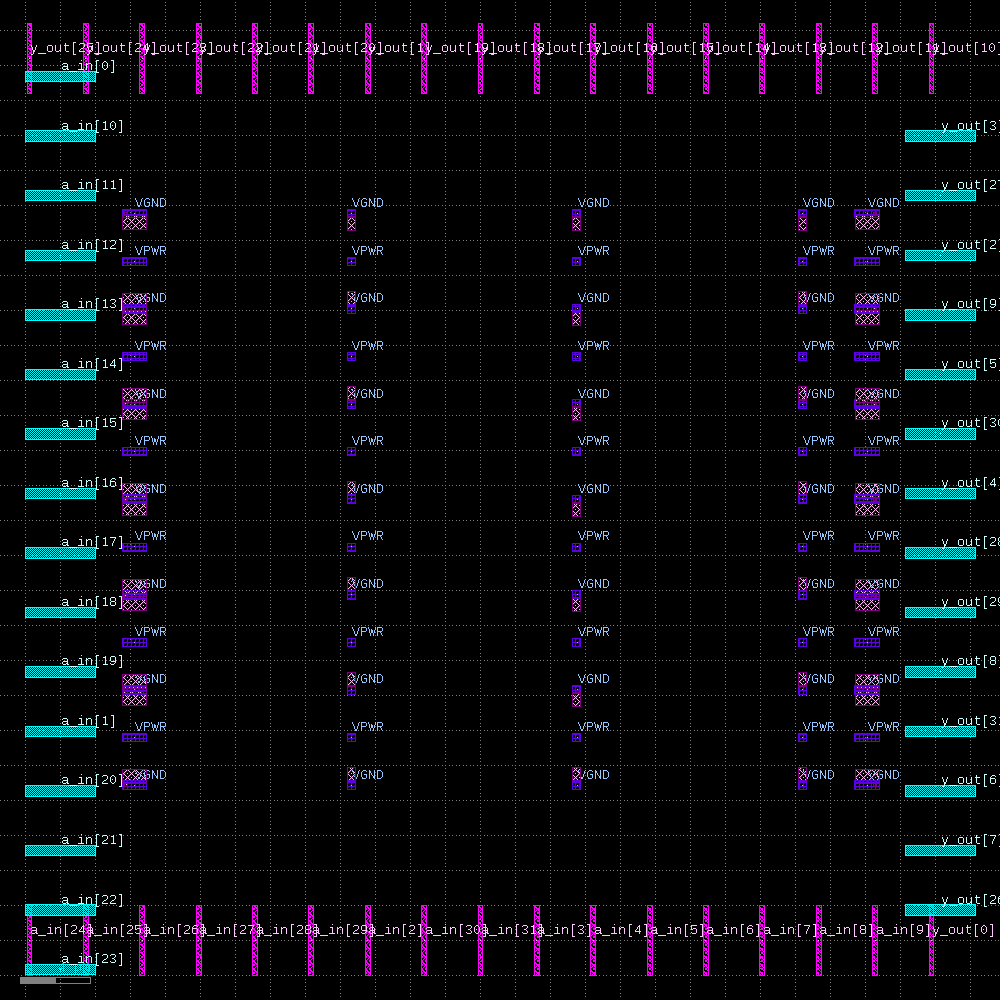

In [ ]:
TapEndcapInsertion = Step.factory.get("OpenROAD.TapEndcapInsertion")
tdi = TapEndcapInsertion(state_in=floorplan.state_out)
tdi.start()

IOPlacement = Step.factory.get("OpenROAD.IOPlacement")
ioplace = IOPlacement(state_in=tdi.state_out)
ioplace.start()
display(ioplace)

If it is **not successful**, return to the first box in **Step 3** and enter a bigger width and height.

Which metal layer(s) is/are used for the I/O pins?

Met2: horizontal, with locations left and right \
Met3: verticial, top and bottom

Estimate the pitch of the I/O pins. The pitch is the distance between two pins.

Estimated pitch: ~ 3 um

As the I/O placer uses a minimum spacing constraint of FP_IO_MIN_DISTANCE = 3 µm (-min_distance 3). Because 64 out of 66 available slots are filled (a 97% fill rate), the pins are placed almost continuously end-to-end along the perimeter.

We will proceed with the remaining steps of the physical implementation.

[15:36:39] INFO     Loading the incremental configuration has generated the following warnings:       ]8;id=404684;file:///content/openlane_ipynb/openlane/config/config.py\config.py]8;;\:]8;id=981196;file:///content/openlane_ipynb/openlane/config/config.py#320\320]8;;\

[15:36:39] WARNING  'FP_PDN_AUTO_ADJUST' has been removed: Too situational. It's always best to be    ]8;id=104230;file:///content/openlane_ipynb/openlane/config/config.py\config.py]8;;\:]8;id=304451;file:///content/openlane_ipynb/openlane/config/config.py#324\324]8;;\
                    more explicit.                                                                                 

────────────────────────────────────── Power Distribution Network Generation ──────────────────────────────────────

[15:36:39] VERBOSE  Running 'OpenROAD.GeneratePDN' at 'openlane_run/10-openroad-generatepdn'…          ]8;id=200334;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=57354;file:///content/openlane_ipynb/openlane/steps/step.py#1122\1122]8;;\

[15:36:39] INFO     'FP_PDN_CFG' not explicitly set, setting it to                                 ]8;id=628082;file:///content/openlane_ipynb/openlane/steps/openroad.py\openroad.py]8;;\:]8;id=805563;file:///content/openlane_ipynb/openlane/steps/openroad.py#1174\1174]8;;\
                    /content/openlane_ipynb/openlane/scripts/openroad/common/pdn_cfg.tcl…                          

...

Writing layout to '/content/openlane_run/12-openroad-detailedplacement/inverter32.def'…

Writing timing constraints to '/content/openlane_run/12-openroad-detailedplacement/inverter32.sdc'…

──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[15:36:44] VERBOSE  Running 'KLayout.Render' at '../tmp/openlane_klayout_tmp_jxd6hmij'…                ]8;id=476888;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=322422;file:///content/openlane_ipynb/openlane/steps/step.py#1122\1122]8;;\

[15:36:44] VERBOSE  Logging subprocess to '../tmp/openlane_klayout_tmp_jxd6hmij/klayout-render.log'…   ]8;id=81503;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=17960;file:///content/openlane_ipynb/openlane/steps/step.py#1318\1318]8;;\

#### Time Elapsed: 1.46s
#### Views updated:
* Verilog Netlist
* Powered Verilog Netlist
* Design Exchange Format
* OpenDB Database
* Design Constraints
#### Preview:
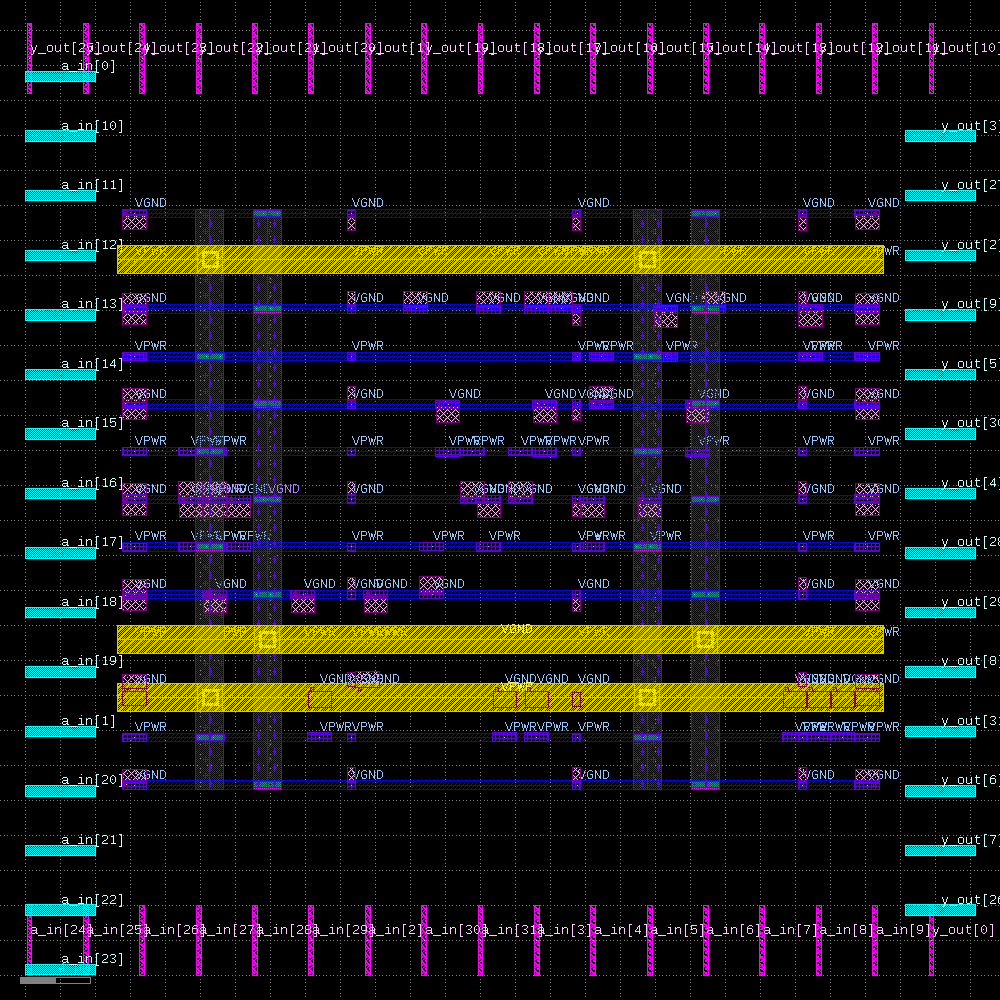

In [ ]:
# generate power distribution network (PDN)
GeneratePDN = Step.factory.get("OpenROAD.GeneratePDN")
pdn = GeneratePDN(
    state_in=ioplace.state_out,
    FP_PDN_AUTO_ADJUST=True,
    FP_PDN_VPITCH=25,
    FP_PDN_HPITCH=25,
    FP_PDN_VOFFSET=5,
    FP_PDN_HOFFSET=5,
)
pdn.start()

# Global placement
GlobalPlacement = Step.factory.get("OpenROAD.GlobalPlacement")
gpl = GlobalPlacement(state_in=pdn.state_out)
gpl.start()

# run detailed placement
DetailedPlacement = Step.factory.get("OpenROAD.DetailedPlacement")
dpl = DetailedPlacement(state_in=gpl.state_out)
dpl.start()

display(dpl)

Next, we will route the design.

───────────────────────────────────────────────── Global Routing ──────────────────────────────────────────────────

[15:36:51] VERBOSE  Running 'OpenROAD.GlobalRouting' at 'openlane_run/13-openroad-globalrouting'…      ]8;id=755018;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=42145;file:///content/openlane_ipynb/openlane/steps/step.py#1122\1122]8;;\

[15:36:51] VERBOSE  Logging subprocess to                                                              ]8;id=918988;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=303619;file:///content/openlane_ipynb/openlane/steps/step.py#1318\1318]8;;\
                    'openlane_run/13-openroad-globalrouting/openroad-globalrouting.log'…                           

Reading OpenROAD database at '/content/openlane_run/12-openroad-detailedplacement/inverter32.odb'…

Reading library file at '/root/.volare/sky130A/libs.ref/sky130_fd_sc_hd/lib/sky130_fd_sc_hd__tt_025C_1v80.lib'…

...

Writing layout to '/content/openlane_run/14-openroad-detailedrouting/inverter32.def'…

Writing timing constraints to '/content/openlane_run/14-openroad-detailedrouting/inverter32.sdc'…

──────────────────────────────────────────── Render Image (w/ KLayout) ────────────────────────────────────────────

[15:36:55] VERBOSE  Running 'KLayout.Render' at '../tmp/openlane_klayout_tmp_yy4__pa1'…                ]8;id=81422;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=110476;file:///content/openlane_ipynb/openlane/steps/step.py#1122\1122]8;;\

[15:36:55] VERBOSE  Logging subprocess to '../tmp/openlane_klayout_tmp_yy4__pa1/klayout-render.log'…   ]8;id=532983;file:///content/openlane_ipynb/openlane/steps/step.py\step.py]8;;\:]8;id=453657;file:///content/openlane_ipynb/openlane/steps/step.py#1318\1318]8;;\

#### Time Elapsed: 2.59s
#### Views updated:
* Verilog Netlist
* Powered Verilog Netlist
* Design Exchange Format
* OpenDB Database
* Design Constraints
#### Preview:
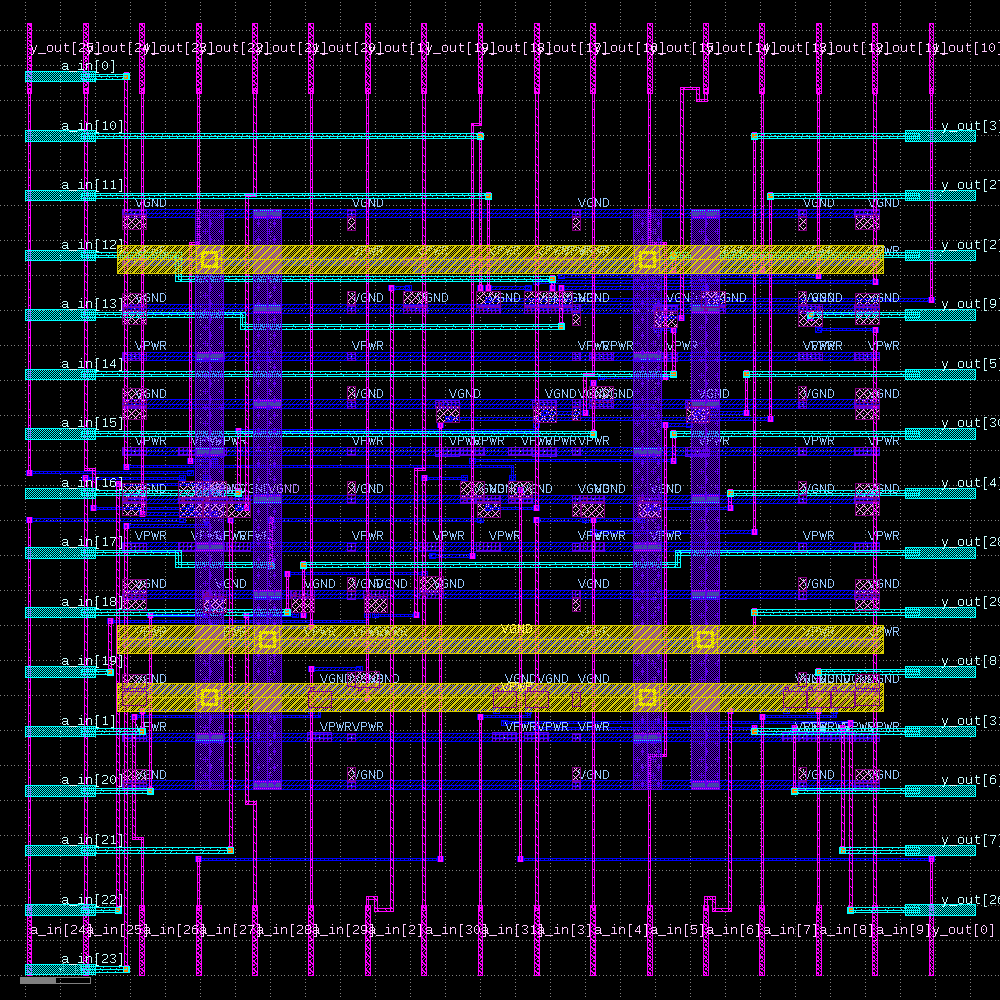

In [ ]:
# Global routing
GlobalRouting = Step.factory.get("OpenROAD.GlobalRouting")
grt = GlobalRouting(state_in=dpl.state_out)
grt.start()

DetailedRouting = Step.factory.get("OpenROAD.DetailedRouting")
drt = DetailedRouting(state_in=grt.state_out)
drt.start()
display(drt)

Inspect the log and the routed design. What is the final total wirelength?

Total wire length = 1,727 um

You may consider this as the length required to connect the logic circuit with the I/O pins.

Please save a copy of the picture of this final layout for your final assignment.

## Step 4: Challenges of inserting I/O pads

From the task above, we have successfully assigned I/O pins around the die, but without any I/O pads. I/O pads are necessary to provide electrical protection and an area for wire bonding.

A typical in-line pad pitch required for 0.18 μm technology is [70 μm](https://www.onsemi.com/PowerSolutions/content.do?id=16679). What would be the dimension of the die if in-line pads are added?

* Horizontal I/O (16 terminals): side length = 16 * 70 um = 1,120 um
* Vertical I/O (17 terminals): side length = 17 * 70 um = 1,190 um

These calculations imply placing individual I/O pads results in a pad-limited design with a lot of empty space. Therefore, as an internal macro block, it lacks the essential elements of a standalone IC, e.g. no pads or independent power ring. To prepare for a complete tapeout and packaging pipeline the design will be integrated into a top-level design alongside other standard logic cells e.g. memory and control logic.

How many percentage of the area is used as the core in this case?

* Core area: 236.48 μm${}^2$
* Total area: 2,952.83 μm${}^2$
* % Utilisation ~ 8 %


---

**What did I learn?**

When you have completed the manual floorplanning to fit in I/O pins and pads, add your thoughts in response to the following question. You will want to keep these, as you will find them useful when working on later modules and your final assignment. To get started, double click this cell and edit the text.

**How does assembly and packaging affect chip design? What are the necessary steps during design to prepare the chip for final packaging?**

At each stage of the design process for the inverter-32 standard cell the following constraints were included to be integrated into a higher level design:

* Floorplanning is directly related to package assembly (keeping critical gates away from edges) and thermal management (cell density determines power density and hotspots)
* Tap & endcap insertion, where taps connects nwells to $V_{DD}$ and pwells to $V_{SS}$ ensure packaging noise does not cause flucuations at the transisitor level and endcaps reduces leakage between channels
* I/O placement maps directly to external block and connections
* Power distribution network ensures the cell connects to package power lines
* Global routing optimises wire length minimising time delays to be connected to other macros



---
You have now reached the end of the notebook for this week. Please return to Canvas to complete the rest of the work in module 5.
